# Summary of All Models

Comprehensive comparison of all computational models of human role choice.

## Models

**Bayesian Models (4):**
| Model | Parameters | Description |
|-------|-----------|-------------|
| **Bayesian Walk** | `tau_prior`, `tau_softmax`, `epsilon`, `epsilon_switch` (4) | Stick-or-switch: mix of staying in current role vs softmax over expected values |
| **Bayesian Threshold** | `tau_prior`, `tau_softmax`, `epsilon`, `delta` (4) | Rational switch: only switch if value gain exceeds threshold delta |
| **Bayesian-Value** | `tau_prior`, `tau_softmax`, `epsilon` (3) | Pure softmax over expected values given posterior beliefs (no sticking) |
| **Bayesian-Belief** | `tau_prior`, `epsilon` (2) | Marginalizes posterior directly for role predictions (no value matrix) |

**Simple Models (2):**
| Model | Parameters | Description |
|-------|-----------|-------------|
| **Random Walk** | `epsilon` (1) | Fixed probability of switching to a random different role |
| **Optimal** | — (0) | Picks highest-value role combo from precomputed MDP values |

**Ensemble (1):**
| Model | Parameters | Description |
|-------|-----------|-------------|
| **Individual-Fitted Mixture** | 7 soft weights per player | For each player, compute a posterior over all 7 models above given their role choices (with 5% lapse rate). At prediction time, each player's role distribution is a weighted blend of all models, using that player's posterior as weights. Team combo predictions multiply the 3 players' marginals. |

**Baselines (5):**
| Model | Description |
|-------|-------------|
| **Random** | Uniform 1/27 over all combos |
| **Top-7** | Uniform over top-7 value combos |
| **Random-to-Optimal** | Linear interpolation from random to optimal across stages |
| **Copy Others** | Copy roles observed from other players |
| **Contradict Others** | Pick roles different from other players |

## Data
- March 6 + March 18 exports (human rounds only, no dropout games)
- 66 team-rounds, 33 participants, 6 environments

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

from shared import EXPORTS_DIR, DATA_ROOT
from shared.constants import (
    F, T, M,
    ROLE_NAMES, ROLE_SHORT, ROLE_CHAR_TO_IDX, GAME_ROLE_TO_IDX,
    ALL_ROLE_COMBOS, TURNS_PER_STAGE,
    ROLE_COMBO_TO_ENV_NUM,
)
from shared.parsing import canonical_combo, get_canonical_combos
from shared.inference import (
    utility_based_prior, uniform_prior,
    bayesian_update, action_prob, preferred_action, game_step,
    softmax_role_dist, combo_marginal,
    ATTACK, DEFEND, HEAL,
)
from shared.evaluation import (
    run_predictions, compute_pearson, compute_log_likelihood, extract_metrics,
)
from shared.data_loading import load_all_exports, to_dataframe
from shared.env_loading import make_env_loader

import warnings
warnings.filterwarnings('ignore')

# Load oms module for team records and Bayesian-Value predictions
OMS_DIR = Path(DATA_ROOT).parent.parent / 'computational_model' / 'analysis'
sys.path.insert(0, str(OMS_DIR))
import online_model_sim as oms

# Monkey-patch oms paths and config loader
oms.VALUE_MATRICES_DIR = DATA_ROOT / 'human_envs_value_matrices'
oms.ENVS_DIR = DATA_ROOT / 'envs'

import re as _re
def _load_config_no_jax(config_path):
    text = Path(config_path).read_text()
    team_max_hp = int(_re.search(r'TEAM_MAX_HP\s*=\s*(\d+)', text).group(1))
    enemy_max_hp = int(_re.search(r'ENEMY_MAX_HP\s*=\s*(\d+)', text).group(1))
    boss_damage = float(_re.search(r'BOSS_DAMAGE\s*=\s*([\d.]+)', text).group(1))
    ps_match = _re.search(r'PLAYER_STATS\s*=\s*(?:jnp\.array|np\.array)?\(?\s*(\[\[.+?\]\])\s*\)?', text, _re.DOTALL)
    rows = _re.findall(r'\[([^\[\]]+)\]', ps_match.group(1))
    player_stats = np.array([[float(x) for x in row.split(',')] for row in rows])
    class Config: pass
    cfg = Config()
    cfg.TEAM_MAX_HP = team_max_hp
    cfg.ENEMY_MAX_HP = enemy_max_hp
    cfg.BOSS_DAMAGE = boss_damage
    cfg.PLAYER_STATS = player_stats
    return cfg

oms.load_config_module = _load_config_no_jax

print("Imports OK")

Imports OK


In [2]:
# Load per-player records (human rounds only, no dropout games)
player_records = load_all_exports(data_dirs=[
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-06-09-54-19',
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-18-15-47-09',
], include_bot_rounds=False, include_dropout_games=False)
df = to_dataframe(player_records)
print(f"{len(df)} player-rounds, {df['participant_id'].nunique()} unique participants")

# Build team-round records with participant IDs
env_loader = make_env_loader()
team_records = []
grouped = df.groupby(['game_id', 'round_number'])

for (game_id, round_num), group in grouped:
    if len(group) != 3:
        continue
    group = group.sort_values('player_id')
    players = group.to_dict('records')
    participant_ids = [p['participant_id'] for p in players]

    n_stages = min(p['n_stages'] for p in players)
    stage_roles = []
    for s in range(n_stages):
        combo = ''.join(ROLE_SHORT[players[pos]['role_idxs'][s]] for pos in range(3))
        stage_roles.append(combo)
    if not stage_roles:
        continue

    config = players[0]['config']
    optimal_roles_idx = config.get('optimalRoles', [])
    role_combo = ''.join(ROLE_SHORT[ri] for ri in optimal_roles_idx)
    stat_profile = players[0]['stat_profile_id']
    lds = [int(c) for c in players[0]['enemy_intent_sequence']]
    env_config = env_loader(role_combo=role_combo)

    team_records.append({
        'game_id': game_id, 'round_number': round_num,
        'env_id': f"{stat_profile}_{role_combo}",
        'stat_profile': stat_profile, 'optimal_roles': role_combo,
        'lds': lds, 'stage_roles': stage_roles,
        'env_config': env_config, 'participant_ids': participant_ids,
    })

all_pids = set()
for rec in team_records:
    for pid in rec['participant_ids']:
        all_pids.add(pid)

# Load oms records (for aggregate benchmarks using oms.run_all_predictions)
oms_records = oms.load_team_rounds(data_dirs=[
    str(EXPORTS_DIR / 'bayesian-role-specialization-2026-03-06-09-54-19'),
    str(EXPORTS_DIR / 'bayesian-role-specialization-2026-03-18-15-47-09'),
])

print(f"Built {len(team_records)} team-round records, {len(all_pids)} participants")
print(f"OMS records: {len(oms_records)} team-rounds, {len(set(r['env_id'] for r in oms_records))} environments")

Loaded bayesian-role-specialization-2026-03-06-09-54-19: 54 player-rounds
Loaded bayesian-role-specialization-2026-03-18-15-47-09: 144 player-rounds
Total: 198 player-rounds from 2 exports
198 player-rounds, 33 unique participants
Built 66 team-round records, 33 participants
OMS records: 66 team-rounds, 6 environments


## Part 1: Aggregate Model Benchmarks

Run all models on 66 team-rounds, evaluate combo-level and marginal-level Pearson correlations.

In [3]:

# ========== MODEL DEFINITIONS ==========

# --- Bayesian Walk ---
def make_bayesian_walk(tau_prior, tau_softmax, epsilon, epsilon_switch):
    def predict_fn(record):
        env = record['env_config']
        values, player_stats = env['values'], env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        results, turn_idx, prev_roles = [], 0, None
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
            intent = record['lds'][turn_idx]
            thp, ehp = int(min(max(0, team_hp), team_max_hp)), int(min(max(0, enemy_hp), enemy_max_hp))
            switch_dist = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax) for i in range(3)]
            per_agent = []
            for i in range(3):
                if prev_roles is None:
                    per_agent.append(switch_dist[i])
                else:
                    stick = np.zeros(3); stick[prev_roles[i]] = 1.0
                    per_agent.append((1.0 - epsilon_switch) * stick + epsilon_switch * switch_dist[i])
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(per_agent[0][r0] * per_agent[1][r1] * per_agent[2][r2])
            results.append({'predicted_dist': predicted_dist, 'human_combo': human_combo,
                           'model_marginal': np.mean(per_agent, axis=0)})
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]; prev_roles = human_roles
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return results
    return predict_fn

# --- Bayesian Threshold ---
def expected_values_per_role(agent_i, intent, team_hp, enemy_hp, prior, values):
    other_agents = [a for a in range(3) if a != agent_i]
    other_probs = np.sum(prior, axis=agent_i)
    total = other_probs.sum()
    other_probs = other_probs / total if total > 0 else np.ones((3, 3)) / 9.0
    ev = np.zeros(3)
    for r_i in range(3):
        for r_j in range(3):
            for r_k in range(3):
                roles = [0,0,0]; roles[agent_i] = r_i; roles[other_agents[0]] = r_j; roles[other_agents[1]] = r_k
                ev[r_i] += other_probs[r_j, r_k] * float(values[roles[0]*9+roles[1]*3+roles[2], intent, team_hp, enemy_hp])
    return ev

def threshold_role_dist(agent_i, intent, team_hp, enemy_hp, prior, values, current_role, delta, tau):
    ev = expected_values_per_role(agent_i, intent, team_hp, enemy_hp, prior, values)
    candidates = [r for r in range(3) if r != current_role and (ev[r] - ev[current_role]) > delta]
    if not candidates:
        dist = np.zeros(3); dist[current_role] = 1.0; return dist
    candidate_vals = np.array([ev[r] for r in candidates])
    scaled = candidate_vals / tau; scaled -= scaled.max()
    exp_vals = np.exp(scaled); probs = exp_vals / exp_vals.sum()
    dist = np.zeros(3)
    for i, r in enumerate(candidates): dist[r] = probs[i]
    return dist

def make_bayesian_thresh(tau_prior, tau_softmax, epsilon, delta):
    def predict_fn(record):
        env = record['env_config']
        values, player_stats = env['values'], env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        results, turn_idx, prev_roles = [], 0, None
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
            intent = record['lds'][turn_idx]
            thp, ehp = int(min(max(0, team_hp), team_max_hp)), int(min(max(0, enemy_hp), enemy_max_hp))
            per_agent = []
            for i in range(3):
                if prev_roles is None:
                    per_agent.append(softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax))
                else:
                    per_agent.append(threshold_role_dist(i, intent, thp, ehp, prior, values,
                        current_role=prev_roles[i], delta=delta, tau=tau_softmax))
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(per_agent[0][r0] * per_agent[1][r1] * per_agent[2][r2])
            results.append({'predicted_dist': predicted_dist, 'human_combo': human_combo,
                           'model_marginal': np.mean(per_agent, axis=0)})
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]; prev_roles = human_roles
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return results
    return predict_fn

# --- Bayesian-Belief ---
def make_bayesian_belief(tau_prior, epsilon):
    def predict_fn(record):
        env = record['env_config']
        player_stats = env['player_stats']
        boss_damage, team_max_hp, enemy_max_hp = env['boss_damage'], env['team_max_hp'], env['enemy_max_hp']
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        results, turn_idx = [], 0
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
            per_agent = []
            for i in range(3):
                marg = np.sum(prior, axis=tuple(j for j in range(3) if j != i))
                total = marg.sum()
                per_agent.append(marg / total if total > 0 else np.ones(3) / 3)
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(per_agent[0][r0] * per_agent[1][r1] * per_agent[2][r2])
            results.append({'predicted_dist': predicted_dist, 'human_combo': human_combo,
                           'model_marginal': np.mean(per_agent, axis=0)})
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return results
    return predict_fn

# --- Random Walk ---
def make_random_walk(eps):
    def predict_fn(record):
        preds = []
        for s, human_combo in enumerate(record['stage_roles']):
            prev = record['stage_roles'][s - 1] if s > 0 else None
            if prev is None:
                dist = {c: 1.0 / 27 for c in ALL_ROLE_COMBOS}
            else:
                dist = {}
                for combo in ALL_ROLE_COMBOS:
                    p = 1.0
                    for i, (c, prev_c) in enumerate(zip(combo, prev)):
                        p *= (1.0 - eps) if c == prev_c else (eps / 2.0)
                    dist[combo] = p
                total = sum(dist.values())
                dist = {c: p / total for c, p in dist.items()}
            marg = np.zeros(3)
            for combo, prob in dist.items():
                for c in combo: marg[ROLE_CHAR_TO_IDX[c]] += prob
            marg /= 3.0
            preds.append({'predicted_dist': dist, 'human_combo': human_combo, 'model_marginal': marg})
        return preds
    return predict_fn

# --- Baselines ---
def run_baseline(records, predict_fn):
    def wrapped(record):
        preds = []
        for s, human_combo in enumerate(record['stage_roles']):
            prev = record['stage_roles'][s - 1] if s > 0 else None
            dist = predict_fn(record, s, prev, record['env_config'])
            marg = np.zeros(3)
            for combo, prob in dist.items():
                for c in combo: marg[ROLE_CHAR_TO_IDX[c]] += prob
            marg /= 3.0
            preds.append({'predicted_dist': dist, 'human_combo': human_combo, 'model_marginal': marg})
        return preds
    return wrapped

def predict_random(record, stage_idx, prev_combo, env_config):
    return {c: 1.0 / 27 for c in ALL_ROLE_COMBOS}

def predict_optimal(record, stage_idx, prev_combo, env_config):
    values = env_config['values']; lds = record['lds']
    turn_idx = stage_idx * TURNS_PER_STAGE
    intent = lds[turn_idx] if turn_idx < len(lds) else 0
    thp, ehp = int(env_config['team_max_hp']), int(env_config['enemy_max_hp'])
    vals = []
    for combo in ALL_ROLE_COMBOS:
        idx = ROLE_CHAR_TO_IDX[combo[0]]*9 + ROLE_CHAR_TO_IDX[combo[1]]*3 + ROLE_CHAR_TO_IDX[combo[2]]
        vals.append(float(values[idx, intent, min(thp, values.shape[2]-1), min(ehp, values.shape[3]-1)]))
    max_val = max(vals)
    optimal = [c for c, v in zip(ALL_ROLE_COMBOS, vals) if abs(v - max_val) < 1e-8]
    dist = {c: 0.0 for c in ALL_ROLE_COMBOS}
    for c in optimal: dist[c] = 1.0 / len(optimal)
    return dist

def make_topk(k=7):
    def predict(record, stage_idx, prev_combo, env_config):
        values = env_config['values']; lds = record['lds']
        turn_idx = stage_idx * TURNS_PER_STAGE
        intent = lds[turn_idx] if turn_idx < len(lds) else 0
        thp, ehp = int(env_config['team_max_hp']), int(env_config['enemy_max_hp'])
        combo_vals = []
        for combo in ALL_ROLE_COMBOS:
            idx = ROLE_CHAR_TO_IDX[combo[0]]*9 + ROLE_CHAR_TO_IDX[combo[1]]*3 + ROLE_CHAR_TO_IDX[combo[2]]
            combo_vals.append((combo, float(values[idx, intent, min(thp, values.shape[2]-1), min(ehp, values.shape[3]-1)])))
        combo_vals.sort(key=lambda x: -x[1])
        dist = {c: 0.0 for c in ALL_ROLE_COMBOS}
        for c, v in combo_vals[:k]: dist[c] = 1.0 / k
        return dist
    return predict

def predict_random_to_optimal(record, stage_idx, prev_combo, env_config):
    alpha = stage_idx / max(len(record['stage_roles']) - 1, 1)
    return {c: (1-alpha)/27 + alpha * predict_optimal(record, stage_idx, prev_combo, env_config).get(c, 0)
            for c in ALL_ROLE_COMBOS}

def predict_copy_others(record, stage_idx, prev_combo, env_config):
    if prev_combo is None: return {c: 1.0/27 for c in ALL_ROLE_COMBOS}
    dist = {}
    for combo in ALL_ROLE_COMBOS:
        p = 1.0
        for i in range(3):
            others = [prev_combo[j] for j in range(3) if j != i]
            p *= 0.5 if combo[i] in others else (0.0 if combo[i] not in others else 0.5)
        dist[combo] = p
    total = sum(dist.values())
    return {c: p/total for c, p in dist.items()} if total > 0 else {c: 1.0/27 for c in ALL_ROLE_COMBOS}

def predict_contradict(record, stage_idx, prev_combo, env_config):
    if prev_combo is None: return {c: 1.0/27 for c in ALL_ROLE_COMBOS}
    dist = {}
    for combo in ALL_ROLE_COMBOS:
        p = 1.0
        for i in range(3):
            others = set(prev_combo[j] for j in range(3) if j != i)
            p *= 1.0 if combo[i] not in others else 0.1
        dist[combo] = p
    total = sum(dist.values())
    return {c: p/total for c, p in dist.items()}

print("All model definitions ready")


All model definitions ready


In [4]:
# Load tuned parameters
PARAMS_DIR = Path('/Users/jolow/coding/bayesian-role-specialization/analysis/experiments/2026-03-29-new-models-all-data')

with open(PARAMS_DIR / 'bayesian_walk' / 'bayesian_walk_params.json') as f:
    bw_params = json.load(f)
with open(PARAMS_DIR / 'bayesian_value' / 'bayesian_value_params.json') as f:
    bv_params = json.load(f)
with open(PARAMS_DIR / 'bayesian_thresh' / 'bayesian_thresh_params.json') as f:
    bt_params = json.load(f)
with open(PARAMS_DIR / 'random_walk' / 'random_walk_params.json') as f:
    rw_params = json.load(f)

import warnings
warnings.filterwarnings('ignore')

# Bayesian-Value in combo-distribution format
def make_bayesian_value_combo(tau_prior, tau_softmax, epsilon):
    def predict_fn(record):
        env = record['env_config']
        values, player_stats = env['values'], env['player_stats']
        boss_damage = env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        results, turn_idx = [], 0
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
            intent = record['lds'][turn_idx]
            thp = int(min(max(0, team_hp), team_max_hp))
            ehp = int(min(max(0, enemy_hp), enemy_max_hp))
            per_agent = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax) for i in range(3)]
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(per_agent[0][r0] * per_agent[1][r1] * per_agent[2][r2])
            results.append({'predicted_dist': predicted_dist, 'human_combo': human_combo,
                           'model_marginal': np.mean(per_agent, axis=0)})
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return results
    return predict_fn

def make_baseline_predict(fn):
    def predict_fn(record):
        preds = []
        for s, human_combo in enumerate(record['stage_roles']):
            prev = record['stage_roles'][s - 1] if s > 0 else None
            dist = fn(record, s, prev, record['env_config'])
            marg = np.zeros(3)
            for combo, prob in dist.items():
                for c in combo: marg[ROLE_CHAR_TO_IDX[c]] += prob
            marg /= 3.0
            preds.append({'predicted_dist': dist, 'human_combo': human_combo, 'model_marginal': marg})
        return preds
    return predict_fn

def eval_model(name, predict_fn, n_params):
    results = run_predictions(team_records, predict_fn)
    corrs = compute_pearson(results)
    ll = compute_log_likelihood(results)
    metrics = extract_metrics(corrs)
    metrics['mean_ll'] = float(np.mean([v['mean_ll'] for v in ll.values()]))
    metrics['n_params'] = n_params
    return name, metrics, corrs, results

# Run all aggregate models on team_records
all_models = []

p = bw_params['aggregate_tuned']
all_models.append(eval_model('Bayesian Walk',
    make_bayesian_walk(p['tau_prior'], p['tau_softmax'], p['epsilon'], p['epsilon_switch']), 4))

p = bt_params['aggregate_tuned']; p = p.get('bayesian_thresh', p)
all_models.append(eval_model('Bayesian Threshold',
    make_bayesian_thresh(p['tau_prior'], p['tau_softmax'], p['epsilon'], p['delta']), 4))

p = bv_params['aggregate_tuned']
all_models.append(eval_model('Bayesian-Value',
    make_bayesian_value_combo(p['tau_prior'], p['tau_softmax'], p['epsilon']), 3))

all_models.append(eval_model('Bayesian-Belief', make_bayesian_belief(tau_prior=2.0, epsilon=0.5), 2))

p = rw_params['aggregate_tuned']
all_models.append(eval_model('Random Walk', make_random_walk(p['eps']), 1))

for bname, fn, n_p in [('Optimal', predict_optimal, 0), ('Top-7', make_topk(7), 0),
                        ('Random-to-Optimal', predict_random_to_optimal, 0),
                        ('Copy Others', predict_copy_others, 0), ('Contradict Others', predict_contradict, 0),
                        ('Random', predict_random, 0)]:
    all_models.append(eval_model(bname, make_baseline_predict(fn), n_p))

# Build summary rows (individual-fitted mixture will be appended in Part 2)
summary_rows = []
for name, metrics, _, _ in all_models:
    summary_rows.append({
        'Model': name,
        'Type': 'Bayesian' if 'Bayesian' in name else ('Simple' if name in ['Random Walk', 'Optimal'] else 'Baseline'),
        'combo_r': metrics['combo_r'], 'marg_r': metrics['marg_r'],
        'mean_ll': metrics['mean_ll'], 'n_params': metrics['n_params'],
    })

print(f"Ran {len(all_models)} aggregate models on team_records ({len(team_records)} rounds)")
for name, m, _, _ in all_models:
    print(f"  {name:22s}: combo_r={m['combo_r']:.4f}, marg_r={m['marg_r']:.4f}, mean_ll={m['mean_ll']:.2f}")

Ran 11 aggregate models on team_records (66 rounds)
  Bayesian Walk         : combo_r=0.4984, marg_r=0.5972, mean_ll=-2.90
  Bayesian Threshold    : combo_r=0.4538, marg_r=0.6349, mean_ll=-21.80
  Bayesian-Value        : combo_r=0.3804, marg_r=0.5151, mean_ll=-4.48
  Bayesian-Belief       : combo_r=0.4732, marg_r=0.3582, mean_ll=-2.66
  Random Walk           : combo_r=0.3825, marg_r=0.4576, mean_ll=-2.83
  Optimal               : combo_r=0.2944, marg_r=0.5058, mean_ll=-34.85
  Top-7                 : combo_r=0.3361, marg_r=0.4500, mean_ll=-20.27
  Random-to-Optimal     : combo_r=0.2518, marg_r=0.4662, mean_ll=-12.02
  Copy Others           : combo_r=0.0025, marg_r=0.4576, mean_ll=-31.14
  Contradict Others     : combo_r=0.1003, marg_r=-0.4733, mean_ll=-4.20
  Random                : combo_r=0.1567, marg_r=nan, mean_ll=-3.30


In [5]:
# === PER-ENVIRONMENT BREAKDOWN ===
env_ids = sorted(set(r['env_id'] for r in team_records))
top_models = ['Bayesian Walk', 'Bayesian Threshold', 'Bayesian-Value', 'Bayesian-Belief', 'Random Walk', 'Optimal']

env_rows = []
for env_id in env_ids:
    row = {'Environment': env_id}
    for name, metrics, corrs, results in all_models:
        if name in top_models:
            env_corr = corrs.get(env_id, {})
            row[name] = env_corr.get('marginal', {}).get('r', float('nan'))
    env_rows.append(row)

env_df = pd.DataFrame(env_rows).set_index('Environment')
print('=== Per-Environment marg_r (top models) ===')
print(env_df[top_models].to_string(float_format='{:.3f}'))

=== Per-Environment marg_r (top models) ===
                 Bayesian Walk  Bayesian Threshold  Bayesian-Value  Bayesian-Belief  Random Walk  Optimal
Environment                                                                                              
114_222_222_MFF          0.398               0.726           0.696            0.261        0.036    0.793
222_222_222_FFF          0.838               0.881           0.776            0.716        0.579    0.763
411_141_114_FFM          0.748               0.660           0.847            0.729        0.724    0.660
411_141_114_FTF          0.780               0.930           0.846           -0.262        0.717    0.720
411_141_114_FTM          0.799               0.527           0.099            0.804        0.790    0.000
411_222_222_FMM          0.231               0.426           0.181            0.292        0.140    0.197


## Part 2: Individual-Level Model Fitting

For each of the 33 participants, compute which model best explains their role choices using posterior model comparison with a lapse rate of 5%.

In [6]:

# ========== INDIVIDUAL MODEL FITTING ==========
# Per-player marginals format models (same as individual_model_fitting experiment)

def marginals_from_combo_dist(combo_dist):
    marginals = [np.zeros(3) for _ in range(3)]
    for combo, prob in combo_dist.items():
        for i, c in enumerate(combo):
            marginals[i][ROLE_CHAR_TO_IDX[c]] += prob
    return marginals

def model_random(record):
    uniform = np.ones(3) / 3.0
    return [[uniform.copy() for _ in range(3)] for _ in record['stage_roles']]

def make_model_random_walk(eps=0.38):
    def model(record):
        stage_marginals = []
        for s, combo in enumerate(record['stage_roles']):
            if s == 0:
                stage_marginals.append([np.ones(3) / 3.0 for _ in range(3)])
            else:
                prev_combo = record['stage_roles'][s - 1]
                player_margs = []
                for i in range(3):
                    marg = np.full(3, eps / 2.0)
                    marg[ROLE_CHAR_TO_IDX[prev_combo[i]]] = 1.0 - eps
                    player_margs.append(marg)
                stage_marginals.append(player_margs)
        return stage_marginals
    return model

def model_optimal(record):
    env = record['env_config']; values = env['values']; lds = record['lds']
    thp = min(int(env['team_max_hp']), values.shape[2] - 1)
    ehp = min(int(env['enemy_max_hp']), values.shape[3] - 1)
    stage_marginals = []
    for s in range(len(record['stage_roles'])):
        turn_idx = s * TURNS_PER_STAGE
        intent = lds[turn_idx] if turn_idx < len(lds) else 0
        vals = []
        for combo in ALL_ROLE_COMBOS:
            idx = ROLE_CHAR_TO_IDX[combo[0]]*9 + ROLE_CHAR_TO_IDX[combo[1]]*3 + ROLE_CHAR_TO_IDX[combo[2]]
            vals.append(float(values[idx, intent, thp, ehp]))
        max_val = max(vals)
        combo_dist = {c: (1.0/sum(1 for v in vals if abs(v-max_val)<1e-8)) if abs(v-max_val)<1e-8 else 0.0
                      for c, v in zip(ALL_ROLE_COMBOS, vals)}
        stage_marginals.append(marginals_from_combo_dist(combo_dist))
    return stage_marginals

def make_model_bv(tau_prior=5.6, tau_softmax=0.1, epsilon=0.2):
    def model(record):
        env = record['env_config']; values = env['values']
        player_stats, boss_damage = env['player_stats'], env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals, turn_idx = [], 0
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
            intent = record['lds'][turn_idx]
            thp, ehp = int(min(max(0, team_hp), team_max_hp)), int(min(max(0, enemy_hp), enemy_max_hp))
            per_agent = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax) for i in range(3)]
            stage_marginals.append(per_agent)
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return stage_marginals
    return model

def make_model_bb(tau_prior=2.0, epsilon=0.5):
    def model(record):
        env = record['env_config']; player_stats = env['player_stats']
        boss_damage, team_max_hp, enemy_max_hp = env['boss_damage'], env['team_max_hp'], env['enemy_max_hp']
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals, turn_idx = [], 0
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
            per_agent = []
            for i in range(3):
                marg = np.sum(prior, axis=tuple(j for j in range(3) if j != i))
                total = marg.sum()
                per_agent.append(marg / total if total > 0 else np.ones(3) / 3)
            stage_marginals.append(per_agent)
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return stage_marginals
    return model

def make_model_bwalk(tau_prior=5.71, tau_softmax=6.37, epsilon=0.20, epsilon_switch=0.35):
    def model(record):
        env = record['env_config']; values = env['values']
        player_stats, boss_damage = env['player_stats'], env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals, turn_idx, prev_roles = [], 0, None
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
            intent = record['lds'][turn_idx]
            thp, ehp = int(min(max(0, team_hp), team_max_hp)), int(min(max(0, enemy_hp), enemy_max_hp))
            switch_dist = [softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax) for i in range(3)]
            per_agent = []
            for i in range(3):
                if prev_roles is None: per_agent.append(switch_dist[i])
                else:
                    stick = np.zeros(3); stick[prev_roles[i]] = 1.0
                    per_agent.append((1.0 - epsilon_switch) * stick + epsilon_switch * switch_dist[i])
            stage_marginals.append(per_agent)
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]; prev_roles = human_roles
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return stage_marginals
    return model

def make_model_bthresh(tau_prior=5.63, tau_softmax=3.86, epsilon=0.17, delta=3.33):
    def model(record):
        env = record['env_config']; values = env['values']
        player_stats, boss_damage = env['player_stats'], env['boss_damage']
        team_max_hp, enemy_max_hp = env['team_max_hp'], env['enemy_max_hp']
        team_hp, enemy_hp = float(team_max_hp), float(enemy_max_hp)
        prior = utility_based_prior(player_stats, tau=tau_prior)
        stage_marginals, turn_idx, prev_roles = [], 0, None
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
            intent = record['lds'][turn_idx]
            thp, ehp = int(min(max(0, team_hp), team_max_hp)), int(min(max(0, enemy_hp), enemy_max_hp))
            per_agent = []
            for i in range(3):
                if prev_roles is None:
                    per_agent.append(softmax_role_dist(i, intent, thp, ehp, prior, values, tau_softmax))
                else:
                    per_agent.append(threshold_role_dist(i, intent, thp, ehp, prior, values,
                        current_role=prev_roles[i], delta=delta, tau=tau_softmax))
            stage_marginals.append(per_agent)
            human_roles = [ROLE_CHAR_TO_IDX[c] for c in human_combo]; prev_roles = human_roles
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or team_hp <= 0 or enemy_hp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(human_roles[i], intent, team_hp, team_max_hp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, team_hp, team_max_hp, epsilon)
                team_hp, enemy_hp = game_step(intent, team_hp, enemy_hp, actions, player_stats, boss_damage, team_max_hp)
                turn_idx += 1
        return stage_marginals
    return model

INDIV_MODELS = {
    'Random': model_random,
    'Random Walk': make_model_random_walk(eps=0.38),
    'Optimal': model_optimal,
    'Bayesian-Value': make_model_bv(tau_prior=5.6, tau_softmax=0.1, epsilon=0.2),
    'Bayesian-Belief': make_model_bb(tau_prior=2.0, epsilon=0.5),
    'Bayesian Walk': make_model_bwalk(tau_prior=5.71, tau_softmax=6.37, epsilon=0.20, epsilon_switch=0.35),
    'Bayesian Threshold': make_model_bthresh(tau_prior=5.63, tau_softmax=3.86, epsilon=0.17, delta=3.33),
}

indiv_model_names = list(INDIV_MODELS.keys())
print(f"Individual models: {indiv_model_names}")


Individual models: ['Random', 'Random Walk', 'Optimal', 'Bayesian-Value', 'Bayesian-Belief', 'Bayesian Walk', 'Bayesian Threshold']


In [7]:

# === Per-player log-likelihoods with lapse rate ===
LAPSE_RATE = 0.05
UNIFORM = np.ones(3) / 3.0

def apply_lapse(marginal, lapse=LAPSE_RATE):
    return (1.0 - lapse) * marginal + lapse * UNIFORM

player_ll = {name: defaultdict(float) for name in INDIV_MODELS}
player_n_stages = defaultdict(int)

for rec in team_records:
    model_outputs = {name: fn(rec) for name, fn in INDIV_MODELS.items()}
    for s, human_combo in enumerate(rec['stage_roles']):
        for pos in range(3):
            pid = rec['participant_ids'][pos]
            actual_role_idx = ROLE_CHAR_TO_IDX[human_combo[pos]]
            player_n_stages[pid] += 1
            for name in INDIV_MODELS:
                margs = model_outputs[name]
                if s < len(margs):
                    prob = apply_lapse(margs[s][pos])[actual_role_idx]
                else:
                    prob = 1.0 / 3.0
                player_ll[name][pid] += np.log(max(prob, 1e-20))

# Build posterior over models per player
indiv_model_names = list(INDIV_MODELS.keys())
posterior_rows = []
for pid in sorted(all_pids):
    lls = np.array([player_ll[name][pid] for name in indiv_model_names])
    log_post = lls - lls.max()
    post = np.exp(log_post); post /= post.sum()
    entry = {'participant_id': pid, 'n_stages': player_n_stages[pid]}
    for i, name in enumerate(indiv_model_names):
        entry[f'P({name})'] = post[i]
    entry['dominant_model'] = indiv_model_names[np.argmax(post)]
    posterior_rows.append(entry)

post_df = pd.DataFrame(posterior_rows)

# Build pid_posteriors and individual predict function (used by unified summary)
pid_posteriors = {}
for _, row in post_df.iterrows():
    pid_posteriors[row['participant_id']] = {name: row[f'P({name})'] for name in indiv_model_names}

def make_individual_predict(posteriors_dict):
    def predict(record):
        model_outputs = {name: fn(record) for name, fn in INDIV_MODELS.items()}
        preds = []
        for s, human_combo in enumerate(record['stage_roles']):
            player_marginals = []
            for pos in range(3):
                pid = record['participant_ids'][pos]
                weights = posteriors_dict[pid]
                mixture = np.zeros(3)
                for name in indiv_model_names:
                    if s < len(model_outputs[name]):
                        mixture += weights[name] * model_outputs[name][s][pos]
                    else:
                        mixture += weights[name] * np.ones(3) / 3.0
                mixture = np.maximum(mixture, 1e-20); mixture /= mixture.sum()
                player_marginals.append(mixture)
            predicted_dist = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        combo = ROLE_SHORT[r0] + ROLE_SHORT[r1] + ROLE_SHORT[r2]
                        predicted_dist[combo] = float(player_marginals[0][r0] * player_marginals[1][r1] * player_marginals[2][r2])
            preds.append({'predicted_dist': predicted_dist, 'human_combo': human_combo,
                         'model_marginal': np.mean(player_marginals, axis=0)})
        return preds
    return predict

print(f'INDIVIDUAL MODEL FITTING — {len(all_pids)} participants, lapse rate={LAPSE_RATE}')
print(f'\n=== Dominant Model Counts ===')
counts = post_df['dominant_model'].value_counts()
for m in indiv_model_names:
    c = counts.get(m, 0)
    print(f"  {m:22s}: {c:2d} players ({c/len(post_df)*100:.0f}%)")


INDIVIDUAL MODEL FITTING — 33 participants, lapse rate=0.05

=== Dominant Model Counts ===
  Random                :  2 players (6%)
  Random Walk           :  9 players (27%)
  Optimal               :  2 players (6%)
  Bayesian-Value        :  1 players (3%)
  Bayesian-Belief       : 10 players (30%)
  Bayesian Walk         :  5 players (15%)
  Bayesian Threshold    :  4 players (12%)


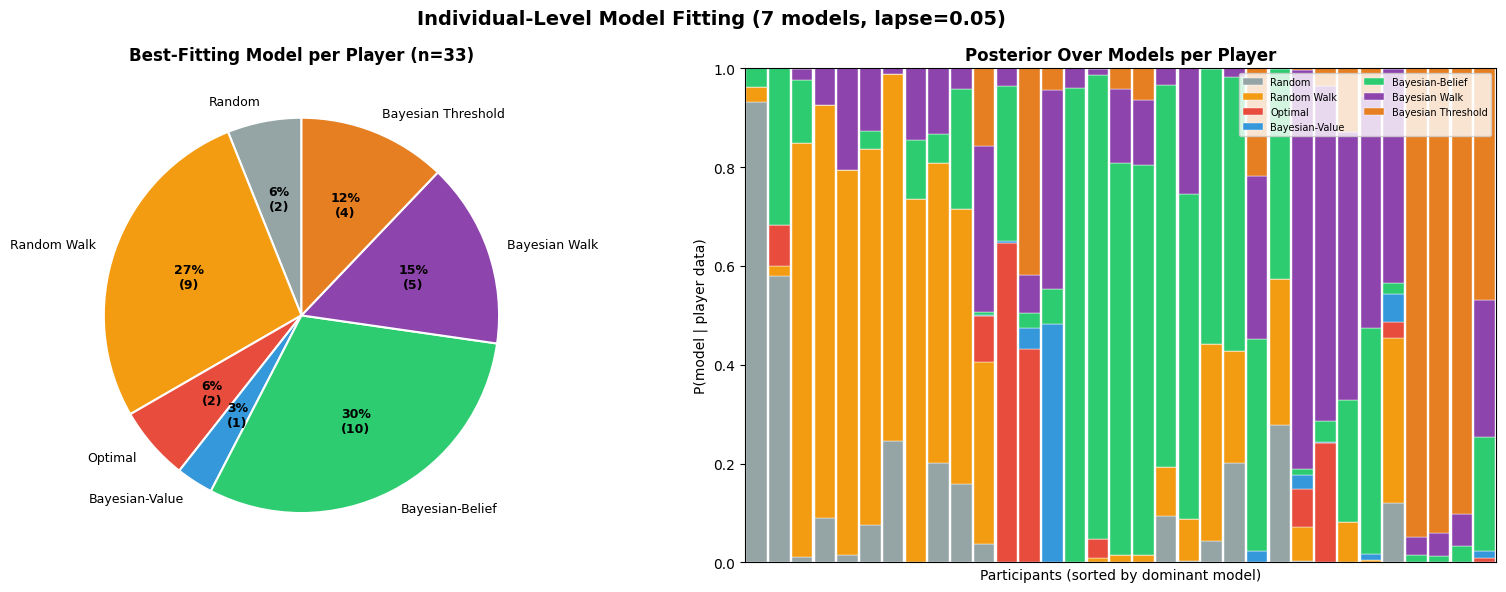

In [8]:

# === Individual fitting visualizations ===
MODEL_COLORS = {
    'Individual-Fitted Mixture': '#9b59b6',
    'Bayesian Walk': '#8e44ad', 'Bayesian Threshold': '#e67e22',
    'Bayesian-Value': '#3498db', 'Bayesian-Belief': '#2ecc71',
    'Random Walk': '#f39c12', 'Optimal': '#e74c3c',
    'Top-7': '#1abc9c', 'Random-to-Optimal': '#34495e',
    'Copy Others': '#7f8c8d', 'Contradict Others': '#c0392b', 'Random': '#95a5a6',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Pie chart ---
ax = axes[0]
counts = post_df['dominant_model'].value_counts().reindex(indiv_model_names, fill_value=0)
counts = counts[counts > 0]
pie_colors = [MODEL_COLORS.get(m, '#95a5a6') for m in counts.index]
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, colors=pie_colors,
    autopct=lambda pct: f'{pct:.0f}%\n({int(round(pct/100*33))})',
    startangle=90, textprops={'fontsize': 9},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
for at in autotexts: at.set_fontweight('bold')
ax.set_title(f'Best-Fitting Model per Player (n=33)', fontsize=12, fontweight='bold')

# --- Stacked bar ---
ax = axes[1]
model_colors_list = [MODEL_COLORS.get(m, '#95a5a6') for m in indiv_model_names]
df_plot = post_df.copy()
model_order = {name: i for i, name in enumerate(indiv_model_names)}
df_plot['sort_model'] = df_plot['dominant_model'].map(model_order)
df_plot['sort_weight'] = df_plot.apply(lambda r: r[f'P({r["dominant_model"]})'], axis=1)
df_plot = df_plot.sort_values(['sort_model', 'sort_weight'], ascending=[True, False]).reset_index(drop=True)

x = np.arange(len(df_plot))
bottoms = np.zeros(len(df_plot))
for i, name in enumerate(indiv_model_names):
    vals = df_plot[f'P({name})'].values
    ax.bar(x, vals, bottom=bottoms, color=model_colors_list[i], label=name, width=0.9,
           edgecolor='white', linewidth=0.3)
    bottoms += vals
ax.set_xlim(-0.5, len(df_plot) - 0.5)
ax.set_ylim(0, 1)
ax.set_xlabel('Participants (sorted by dominant model)')
ax.set_ylabel('P(model | player data)')
ax.set_title(f'Posterior Over Models per Player', fontsize=12, fontweight='bold')
ax.set_xticks([])
ax.legend(loc='upper right', fontsize=7, ncol=2)

plt.suptitle('Individual-Level Model Fitting (7 models, lapse=0.05)', fontsize=14, fontweight='bold')
plt.tight_layout()
SAVE_DIR = Path('/Users/jolow/coding/bayesian-role-specialization/analysis/experiments/2026-03-30-summary-of-all-models')
plt.savefig(SAVE_DIR / 'individual_fitting.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:

# === Add Individual-Fitted Mixture and produce unified summary ===
indiv_results = run_predictions(team_records, make_individual_predict(pid_posteriors))
indiv_corrs = compute_pearson(indiv_results)
indiv_ll = compute_log_likelihood(indiv_results)
indiv_m = extract_metrics(indiv_corrs)
indiv_m['mean_ll'] = float(np.mean([v['mean_ll'] for v in indiv_ll.values()]))
indiv_m['n_params'] = 7

summary_rows.append({
    'Model': 'Individual-Fitted Mixture', 'Type': 'Ensemble',
    'combo_r': indiv_m['combo_r'], 'marg_r': indiv_m['marg_r'],
    'mean_ll': indiv_m['mean_ll'], 'n_params': indiv_m['n_params'],
})
summary_df = pd.DataFrame(summary_rows).set_index('Model')
summary_df = summary_df.sort_values('combo_r', ascending=False)

print('='*80)
print('UNIFIED MODEL COMPARISON — 66 team-rounds, 6 environments, 33 participants')
print('='*80)
print(summary_df.to_string(float_format='{:.4f}'.format))
print(f'\nBest combo_r: {summary_df.combo_r.idxmax()} ({summary_df.combo_r.max():.4f})')
print(f'Best marg_r:  {summary_df.marg_r.idxmax()} ({summary_df.marg_r.max():.4f})')
print(f'Best mean_ll: {summary_df.mean_ll.idxmax()} ({summary_df.mean_ll.max():.4f})')

best_agg = summary_df.drop('Individual-Fitted Mixture').combo_r.max()
best_agg_name = summary_df.drop('Individual-Fitted Mixture').combo_r.idxmax()
print(f'\nIndiv-fitted improvement over best aggregate ({best_agg_name}): +{indiv_m["combo_r"] - best_agg:.4f} ({(indiv_m["combo_r"] - best_agg)/best_agg*100:.1f}%)')


UNIFIED MODEL COMPARISON — 66 team-rounds, 6 environments, 33 participants
                               Type  combo_r  marg_r  mean_ll  n_params
Model                                                                  
Individual-Fitted Mixture  Ensemble   0.5916  0.6415  -2.2157         7
Bayesian Walk              Bayesian   0.4984  0.5972  -2.8968         4
Bayesian-Belief            Bayesian   0.4732  0.3582  -2.6613         2
Bayesian Threshold         Bayesian   0.4538  0.6349 -21.7973         4
Random Walk                  Simple   0.3825  0.4576  -2.8265         1
Bayesian-Value             Bayesian   0.3804  0.5151  -4.4798         3
Top-7                      Baseline   0.3361  0.4500 -20.2657         0
Optimal                      Simple   0.2944  0.5058 -34.8515         0
Random-to-Optimal          Baseline   0.2518  0.4662 -12.0184         0
Random                     Baseline   0.1567     NaN  -3.2958         0
Contradict Others          Baseline   0.1003 -0.4733  -4.2018

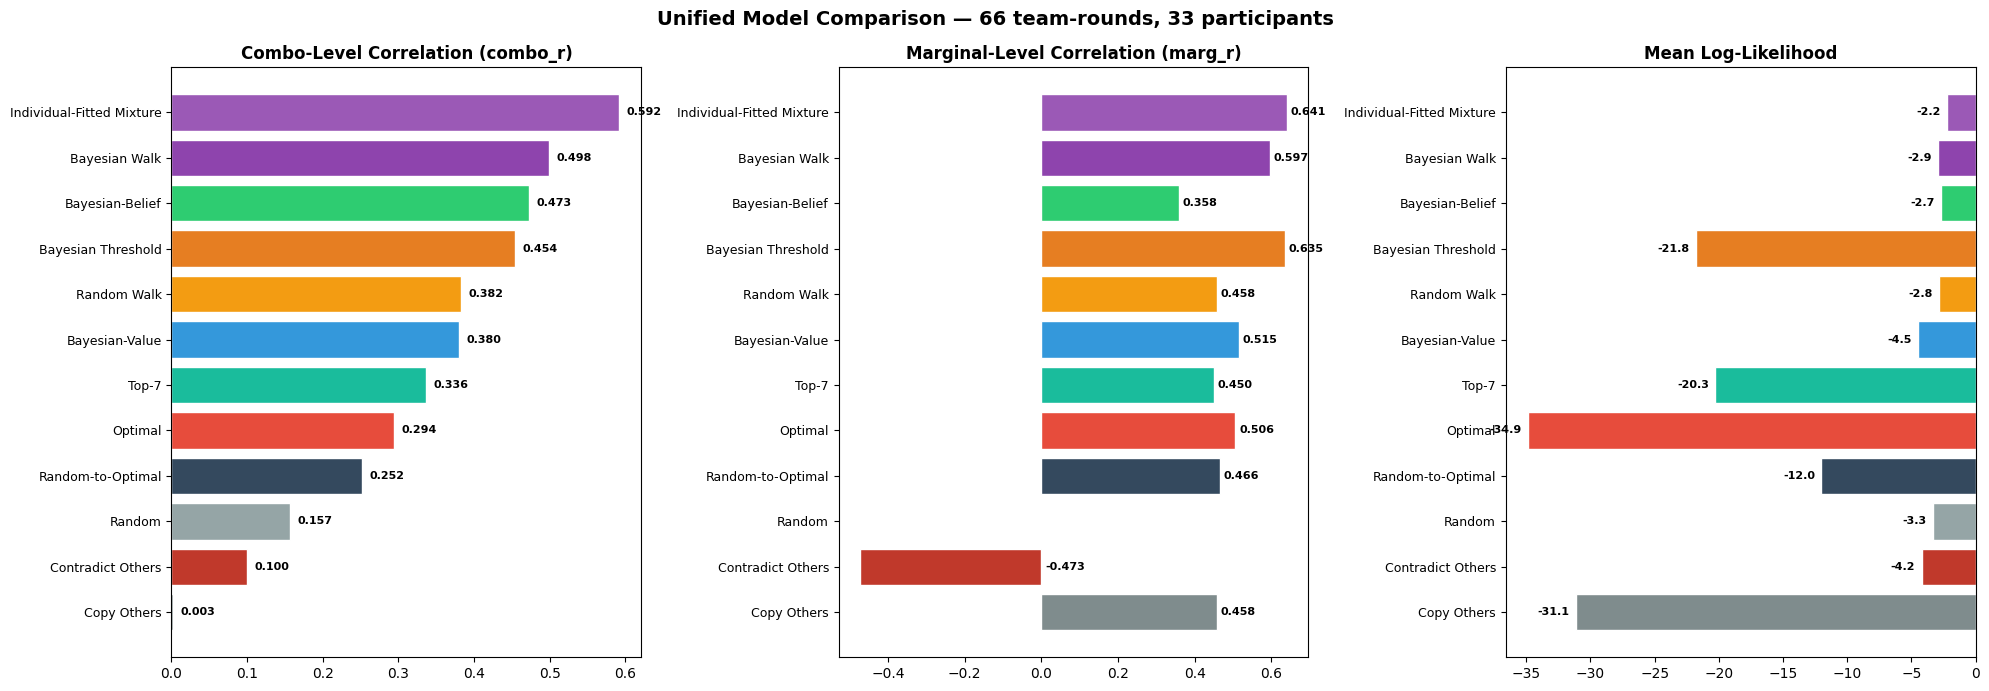

In [10]:

# === UNIFIED VISUALIZATION ===
SAVE_DIR = Path('/Users/jolow/coding/bayesian-role-specialization/analysis/experiments/2026-03-30-summary-of-all-models')

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
ordered = summary_df.index.tolist()
colors = [MODEL_COLORS.get(m, '#95a5a6') for m in ordered]

for ax, col, title in [(axes[0], 'combo_r', 'Combo-Level Correlation (combo_r)'),
                         (axes[1], 'marg_r', 'Marginal-Level Correlation (marg_r)'),
                         (axes[2], 'mean_ll', 'Mean Log-Likelihood')]:
    vals = [summary_df.loc[m, col] for m in ordered]
    ax.barh(range(len(ordered)), vals, color=colors, edgecolor='white')
    ax.set_yticks(range(len(ordered)))
    ax.set_yticklabels(ordered, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    for i, (m, v) in enumerate(zip(ordered, vals)):
        if not np.isnan(v):
            if col == 'mean_ll':
                ax.text(min(v, 0) - 0.5, i, f'{v:.1f}', va='center', fontsize=8, fontweight='bold', ha='right')
            else:
                ax.text(max(v, 0) + 0.01, i, f'{v:.3f}', va='center', fontsize=8, fontweight='bold')

plt.suptitle('Unified Model Comparison — 66 team-rounds, 33 participants', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Key Findings

### Aggregate Benchmarks (team-level, 66 rounds)
- **Bayesian Walk** is the best single aggregate model (combo_r=0.498, marg_r=0.597)
- **Bayesian-Belief** has the best log-likelihood (-2.66) and is competitive on combo_r (0.473)
- All 4 Bayesian models outperform all baselines on combo_r
- **Random Walk** (1 param) is competitive with multi-parameter Bayesian models

### Individual Model Fitting (33 participants)
- **Players are heterogeneous**: no single model dominates
  - Bayesian-Belief: 30%, Random Walk: 27%, Bayesian Walk: 15%, Bayesian Threshold: 12%
  - 60% of players are best explained by Bayesian models
- **Individual-fitted mixture is the best overall model** (combo_r=0.592, marg_r=0.642)
  - +18.7% combo_r over the best aggregate model (Bayesian Walk)
  - Captures player heterogeneity: different players use different strategies